In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import ifft, fft, fftfreq, fftshift, ifft2, fft2
from scipy.io import wavfile
from scipy.signal import hilbert
from audio_function import *

Данные загружены


In [2]:
fs, data_micr_calibr =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1847/MIC2.WAV')

fs, data_micr_noise_big =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1842/MIC2.WAV')
fs, data_pgd_noise_big =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1842/MIC1.WAV')

fs, data_micr_noise =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1832/MIC2.WAV')
fs, data_pgd_noise =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1832/MIC1.WAV')

# fs, data_micr_self_noise =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_1011/TASCAM_0328S1.wav')
# fs, data_pgd_self_noise =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_1011/TASCAM_0328S2.wav')

# fs, data_pgd_calibr =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0098S2.wav')

rho = 1.2255
c = 340

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/370336292.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data_micr_calibr =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1847/MIC2.WAV')
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/370336292.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data_micr_noise_big =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1842/MIC2.WAV')
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/370336292.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data_pgd_noise_big =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/2025_1003/2025_1003_1842/MIC1.WAV')
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/370336292.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data_micr_noise =  

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


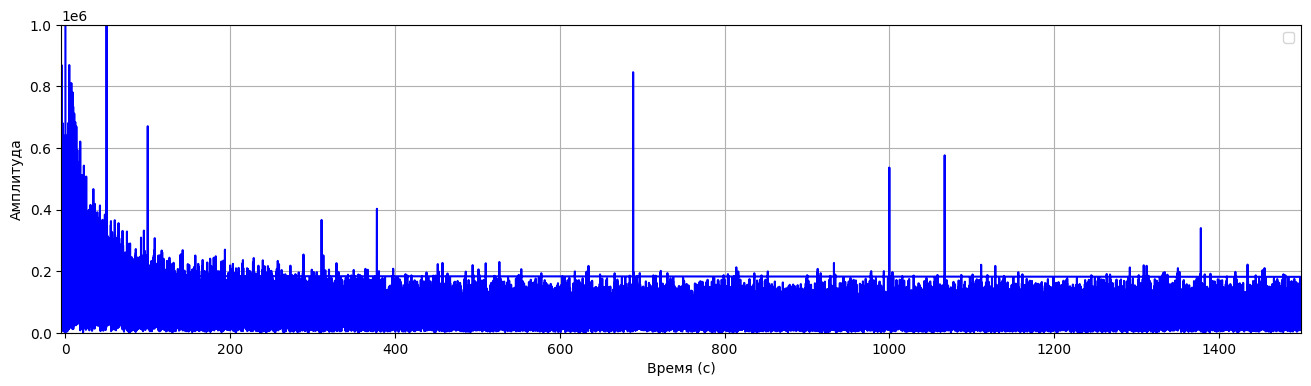

In [ ]:
signal = data_pgd_noise_big
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs((fft(signal))), color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.xlim(-5, 1500)
plt.ylim(0, 1e6)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


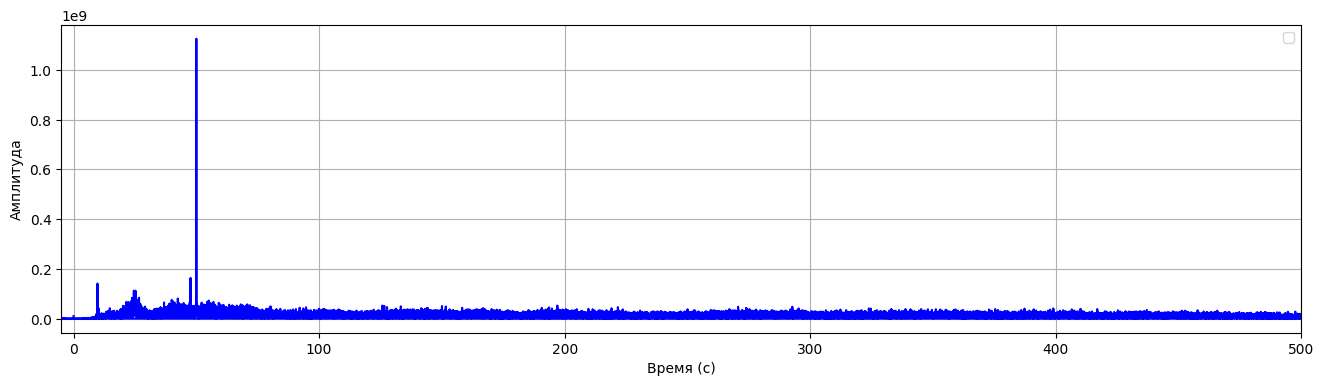

In [6]:
signal = data_pgd_noise_big
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs((fft(signal))), color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.xlim(-5, 500)
# plt.ylim(0, 1e11)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


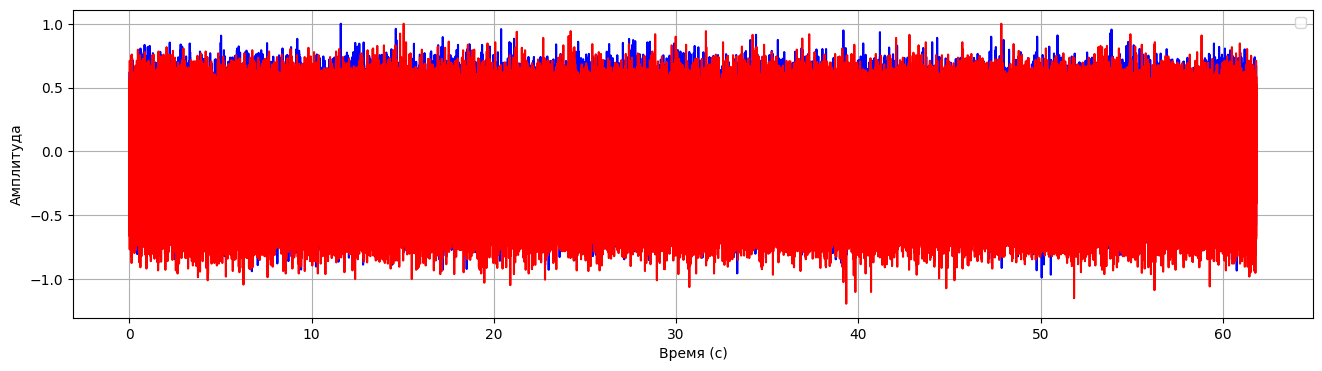

In [10]:
signal1 = data_micr_noise
signal2 = data_pgd_noise
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t, (((signal1/ np.max(signal1)))), color='blue')
plt.plot(t, (((signal2/ np.max(signal2)))), color='red')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
# plt.xlim(14, 19)
# plt.ylim(0, 1e10)
plt.show()

In [13]:
import numpy as np

def generate_octave_bands(octave_fraction=12, f_low=80, f_high=10000, f_ref=1000):
    """
    Генерация октавных полос аналогично MATLAB коду
    
    Parameters:
    octave_fraction : int - дробность октавы (3, 6, 12, 24, 48)
    f_low : float - нижняя частота диапазона (Гц)
    f_high : float - верхняя частота диапазона (Гц) 
    f_ref : float - опорная частота (Гц)
    """
    # Вычисляем индексы как в MATLAB
    start_idx = np.round(np.log2(f_low/f_ref) * octave_fraction) + 1
    end_idx = np.round(np.log2(f_high/f_ref) * octave_fraction) - 1
    
    # Создаем диапазон индексов
    indices = np.arange(start_idx, end_idx + 1)  # +1 т.к. в Python конец не включается
    
    # Центральные частоты
    f0 = f_ref * 2.**(indices / octave_fraction)
    
    # Граничные частоты
    bandwidth_factor = 2**(1/(2*octave_fraction))
    f_down = f0 / bandwidth_factor
    f_up = f0 * bandwidth_factor
    
    return f0, f_down, f_up

# --- Примеры использования (аналогично MATLAB коду) ---

print("=== 1/12 октавы (как в активном коде) ===")
f0, f_down, f_up = generate_octave_bands(octave_fraction=12, f_low=80, f_high=10000)
# print(f"Центральные частоты: {f0}")
# print(f"Нижние границы: {f_down}")
# print(f"Верхние границы: {f_up}")


=== 1/12 октавы (как в активном коде) ===


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


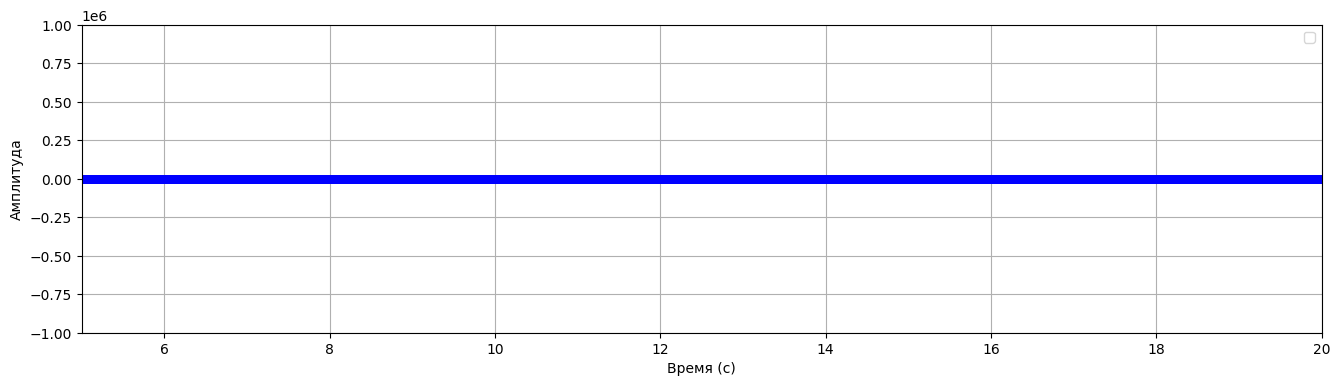

In [14]:
t_micr_calibr = np.arange(len(data_micr_calibr))/fs
f_micr_calibr = fftfreq(len(data_micr_calibr), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_micr_calibr, data_micr_calibr, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.xlim(5, 20)
plt.ylim(-1e6, 1e6)
plt.grid(True)
plt.show()

In [8]:
# Выделям временной участок, на котором калибровка чистая
t_index = (t_micr_calibr > 14) & (t_micr_calibr < 19)
t_1000Hz = t_micr_calibr[t_index]

data_micr_calibr_5sec = data_micr_calibr[t_index]

In [9]:
# Находим коэффициент усиления шумомера и учитываем его
data_micr_calibr_5sec = ifft(filt_freq(fft(data_micr_calibr_5sec), 990, 1010, fs))
impl_dB = 20
k_impl = 10**(impl_dB/20)

data_micr_calibr_5sec = data_micr_calibr_5sec / k_impl
data_micr_calibr = data_micr_calibr / k_impl
data_micr_noise_big = data_micr_noise_big / k_impl
data_micr_noise_big_wo = data_micr_noise_big_wo / k_impl
data_micr_self_noise = data_micr_self_noise / k_impl

# Находим коэффициента пересчета из отн. ед. в 
k_t = RMS(data_micr_calibr_5sec)
k_to_pa = 1 / k_t
k_to_pa

1.605333646835149e-05

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


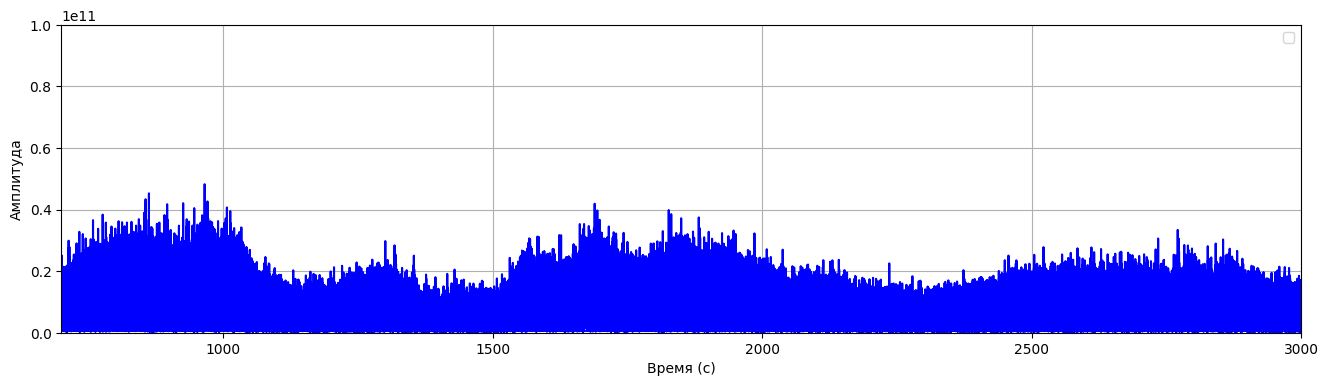

In [10]:
signal = data_micr_noise_big
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs((fft(signal))), color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.xlim(700, 3000)
plt.ylim(0, 1e11)
plt.show()

In [11]:
data_micr_calibr_pa = data_micr_calibr * k_to_pa
data_micr_noise_big_pa = data_micr_noise_big * k_to_pa
data_micr_noise_big_wo_pa = data_micr_noise_big_wo * k_to_pa
data_micr_self_noise = data_micr_self_noise * k_to_pa

In [12]:
max(data_micr_noise_big)

11212569.6

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


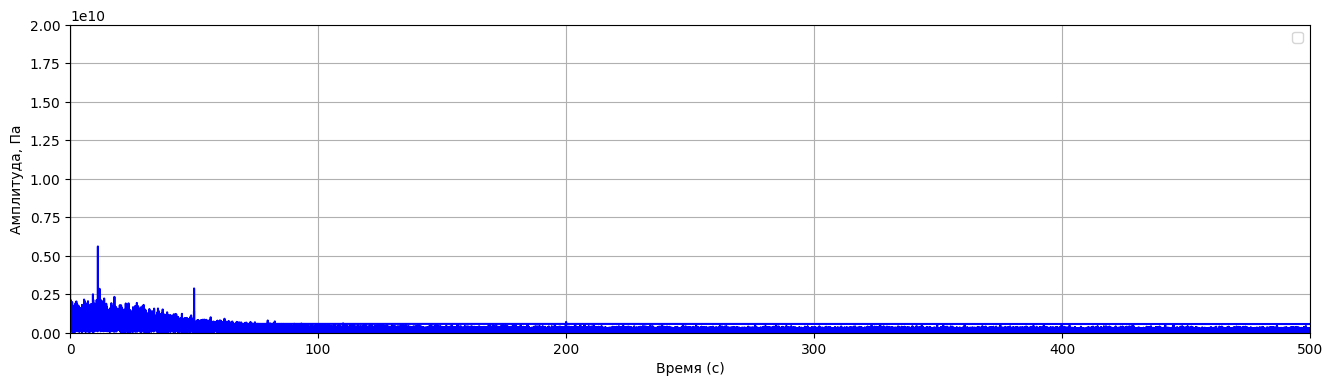

In [13]:
signal = data_pgd_self_noise
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs((fft(signal))), color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда, Па")
plt.grid(True)
plt.xlim(0, 500)
plt.ylim(0, 20000000000)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


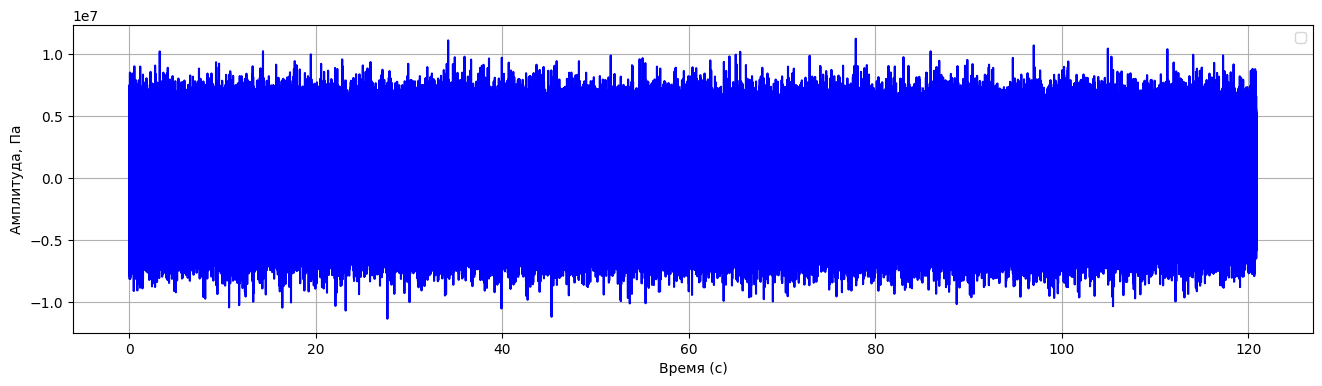

In [14]:
signal = data_micr_noise_big
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t, (((signal))), color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда, Па")
plt.grid(True)
# plt.xlim(0, 500)
# plt.ylim(0, 0.002)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


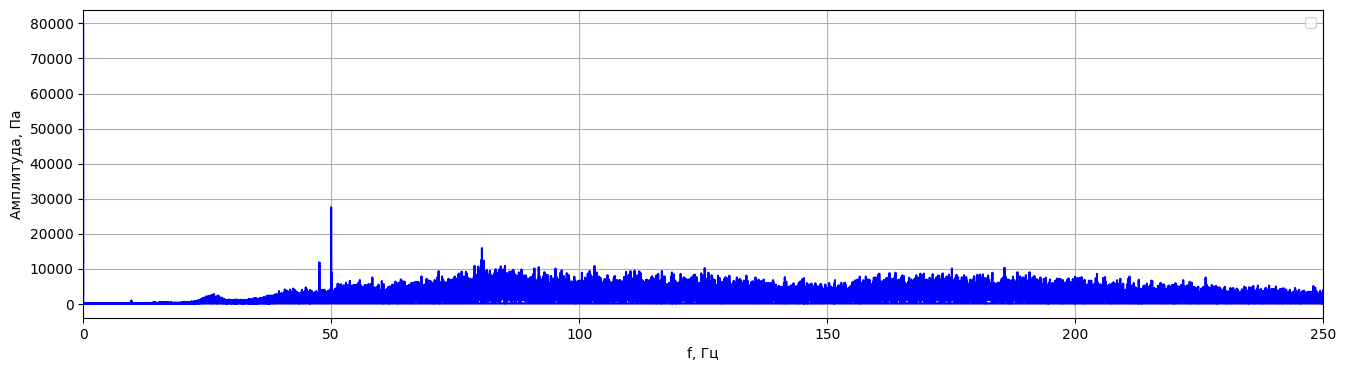

In [15]:
signal = data_micr_noise_big
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs(fft(signal))/len(signal), color='blue')
plt.legend()
plt.xlabel("f, Гц")
plt.ylabel("Амплитуда, Па")
plt.grid(True)
plt.xlim(0, 250)
# plt.ylim(0, 0.00008)
plt.show()

In [16]:
signal = data_pgd_calibr - np.mean(data_pgd_calibr)
data_micr_noise_big_pa_rms = RMS(data_micr_noise_big_pa)
dB_level = 20 * np.log10(data_micr_noise_big_pa_rms / 2e-5)
dB_level

124.65846993285558

In [17]:
data_micr_calibr_rms = RMS(data_micr_calibr_pa)
dB_level = 20 * np.log10(data_micr_calibr_rms / 2e-5)
dB_level

117.54668068683588

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


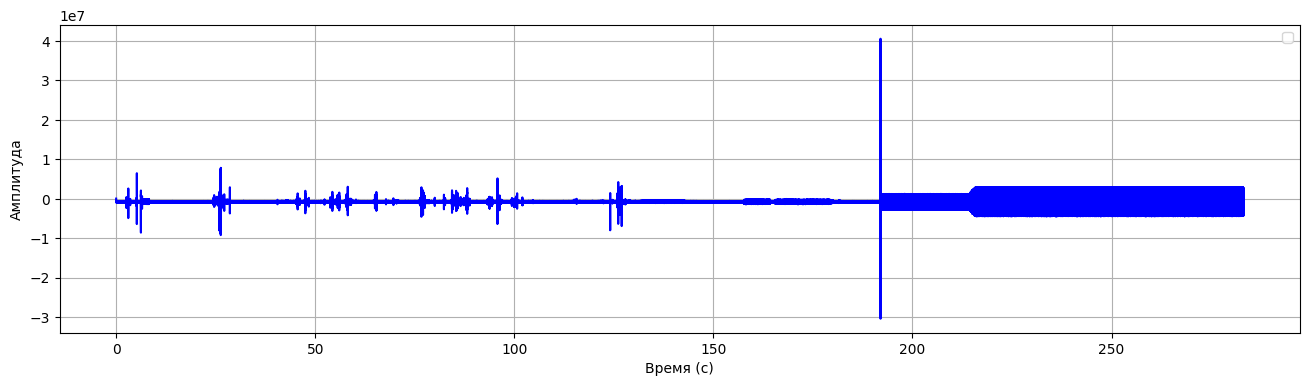

In [18]:
t_pgd_calibr = np.arange(len(data_pgd_calibr))/fs
f_pgd_calibr = fftfreq(len(data_pgd_calibr), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_pgd_calibr, data_pgd_calibr, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

In [19]:
# Выделям временной участок, на котором калибровка
t_index = (t_pgd_calibr > 240) & (t_pgd_calibr < 245)
t_1000Hz = t_pgd_calibr[t_index]

data_pgd_calibr_5sec = data_pgd_calibr[t_index]

In [20]:
RMS_gen = RMS(data_pgd_calibr_5sec)
mv_gen = 362
k_to_mv = mv_gen / RMS_gen

data_pgd_noise_big_mv = data_pgd_noise_big * k_to_mv
data_pgd_noise_big_wo_mv = data_pgd_noise_big_wo * k_to_mv
data_pgd_self_noise_mv = data_pgd_self_noise * k_to_mv
k_to_mv

0.07624591375991366

In [21]:
# Задаем 2 массива RMS по октавным фильтрам для рассчета коэффициента чувствительности в мВ/Па
# Z0 = rho*c
# data_micr_noise_big_vel = data_micr_noise_big_pa / Z0

data_micr_noise_big_pa = data_micr_noise - np.mean(data_micr_noise)
data_pgd_noise_big_mv = data_pgd_noise - np.mean(data_pgd_noise)

amplitudes_microphone = []
for f1, f2 in zip(f_down, f_up):
    data_1_filt = ifft(filt_freq(fft(data_micr_noise_big_pa), f1, f2, fs))
    amp = RMS(data_1_filt)
    amplitudes_microphone.append(amp)

amplitudes_PGD = []
for f1, f2 in zip(f_down, f_up):
    data_2_filt = ifft(filt_freq(fft(data_pgd_noise_big_mv), f1, f2, fs))
    amp = RMS(data_2_filt)
    amplitudes_PGD.append(amp)

amplitudes_microphone = np.array(amplitudes_microphone)
amplitudes_PGD = np.array(amplitudes_PGD)
calibration_coef = amplitudes_PGD / amplitudes_microphone

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/3417339949.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='blue')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


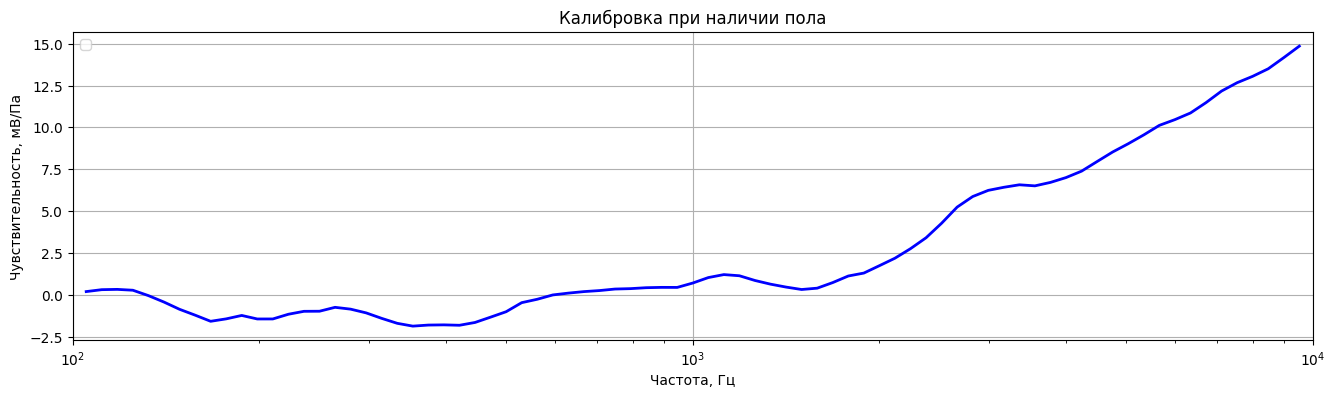

In [22]:
from scipy import interpolate

dB_level_calibr = 20 * np.log10( calibration_coef / calibration_coef[0])

def moving_average(data, window_size):
    """Скользящее среднее"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 5
y_smooth = moving_average(dB_level_calibr, window)

plt.figure(figsize=(16,4))
plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='blue')
plt.legend()
plt.xlabel("Частота, Гц")
plt.ylabel("Чувствительность, мВ/Па")
plt.grid(True)
plt.title('Калибровка при наличии пола')
plt.xscale('log')
plt.xlim(100, 10001)
plt.show()


/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/300855051.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0, dB_level_calibr, 'r-', linewidth=2, color='blue')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


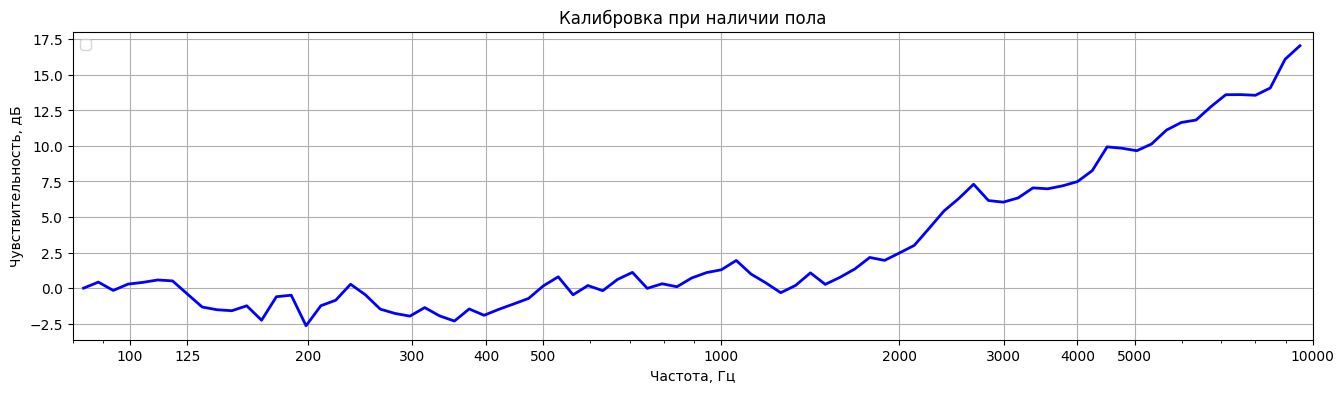

In [23]:
desired_ticks =[
    100, 125, 200, 300, 400, 500, 1000,
    2000, 3000, 4000, 5000, 10000
]
plt.figure(figsize=(16,4))
plt.plot(f0, dB_level_calibr, 'r-', linewidth=2, color='blue')
plt.legend()
plt.xlabel("Частота, Гц")
plt.ylabel("Чувствительность, дБ")
plt.grid(True)
plt.xscale('log')
plt.xlim(80, 10001)
plt.title('Калибровка при наличии пола')
plt.xticks(desired_ticks, [str(t) for t in desired_ticks])
plt.show()

In [24]:
# Задаем 2 массива RMS по октавным фильтрам для рассчета коэффициента чувствительности в мВ/Па
# Z0 = rho*c
# data_micr_noise_big_vel = data_micr_noise_big_pa / Z0

data_micr_noise_big_pa = data_micr_noise_big - np.mean(data_micr_noise_big)
data_pgd_noise_big_mv = data_pgd_noise_big - np.mean(data_pgd_noise_big)

amplitudes_microphone = []
for f1, f2 in zip(f_down, f_up):
    data_1_filt = ifft(filt_freq(fft(data_micr_noise_big_pa), f1, f2, fs))
    amp = RMS(data_1_filt)
    amplitudes_microphone.append(amp)

amplitudes_PGD = []
for f1, f2 in zip(f_down, f_up):
    data_2_filt = ifft(filt_freq(fft(data_pgd_noise_big_mv), f1, f2, fs))
    amp = RMS(data_2_filt)
    amplitudes_PGD.append(amp)

amplitudes_microphone = np.array(amplitudes_microphone)
amplitudes_PGD = np.array(amplitudes_PGD)
calibration_coef = amplitudes_PGD / amplitudes_microphone

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/3417339949.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='blue')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


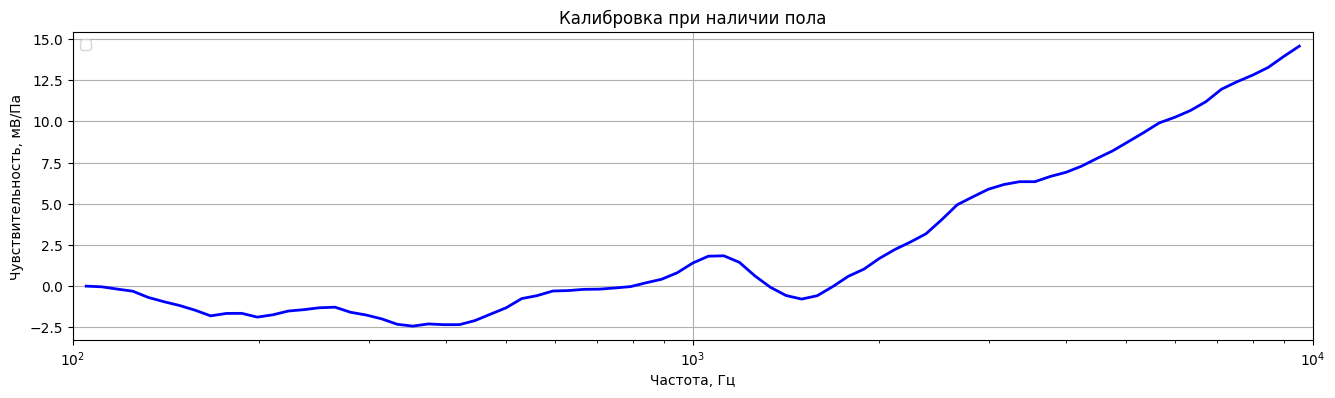

In [25]:
from scipy import interpolate

dB_level_calibr = 20 * np.log10( calibration_coef / calibration_coef[0])

def moving_average(data, window_size):
    """Скользящее среднее"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 5
y_smooth = moving_average(dB_level_calibr, window)

plt.figure(figsize=(16,4))
plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='blue')
plt.legend()
plt.xlabel("Частота, Гц")
plt.ylabel("Чувствительность, мВ/Па")
plt.grid(True)
plt.title('Калибровка при наличии пола')
plt.xscale('log')
plt.xlim(100, 10001)
plt.show()


/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2262/300855051.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0, dB_level_calibr, 'r-', linewidth=2, color='blue')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


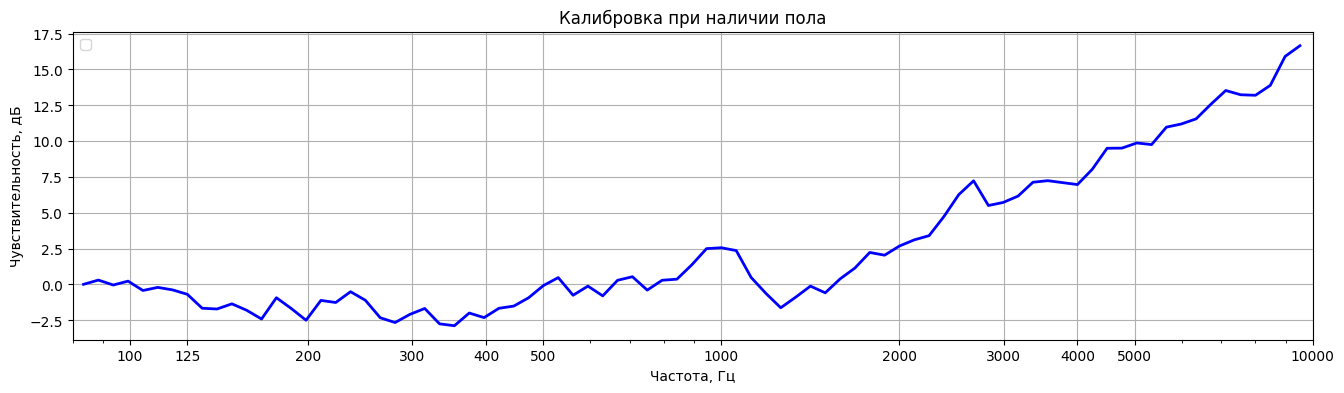

In [26]:
desired_ticks =[
    100, 125, 200, 300, 400, 500, 1000,
    2000, 3000, 4000, 5000, 10000
]
plt.figure(figsize=(16,4))
plt.plot(f0, dB_level_calibr, 'r-', linewidth=2, color='blue')
plt.legend()
plt.xlabel("Частота, Гц")
plt.ylabel("Чувствительность, дБ")
plt.grid(True)
plt.xscale('log')
plt.xlim(80, 10001)
plt.title('Калибровка при наличии пола')
plt.xticks(desired_ticks, [str(t) for t in desired_ticks])
plt.show()